**TAISS 2026 - Filière F1 (Data Science)**

**TP2 - Segmentation RFM**

**Partie 3 : Clustering et choix de k**

**Entrées :** `../data/processed/rfm_scaled.parquet` (matrice standardisée pour le clustering),
`../data/processed/rfm_features.parquet` (valeurs RFM en unités réelles, pour l'interprétation)

**Sortie :** `../data/processed/clusters.parquet` — un `CustomerID` par ligne avec son numéro de
segment, prêt pour la caractérisation en Partie 4.

**Objectif :** on ne cherche pas le k qui minimise le mieux une métrique statistique dans l'absolu,
mais le k qui offre le meilleur compromis entre qualité statistique de la partition et
interprétabilité métier (un marketing ne peut pas gérer 12 segments).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

PROC = Path("../data/processed")
FIG = Path("../figures")
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Chargement des données

In [2]:
X = pd.read_parquet(PROC / "rfm_scaled.parquet")
rfm = pd.read_parquet(PROC / "rfm_features.parquet")

FEATURES = ["R_scaled", "F_scaled", "M_scaled"]

print("Matrice de clustering :", X.shape)
display(X.head())

assert X["CustomerID"].is_unique, "CustomerID en double dans rfm_scaled.parquet"
assert X["CustomerID"].isin(rfm["CustomerID"]).all(), "Clients absents de rfm_features.parquet"

Matrice de clustering : (5878, 4)


,CustomerID,R_scaled,F_scaled,M_scaled
0,12346,0.856701,1.254496,3.206219
1,12347,-2.151979,0.800166,1.215993
2,12348,-0.079138,0.299207,0.573185
3,12349,-0.935308,0.073946,1.139846
4,12350,0.824527,-1.058146,-0.723024


## 2. Méthode du coude et score de silhouette

L'inertie (somme des distances au centroïde) **diminue toujours** quand k augmente — même sans
vraie structure dans les données, k=n_clients donne une inertie nulle. Elle sert seulement à
repérer un "coude" (rendement décroissant), pas à choisir k directement.

Le score de silhouette (borné [-1, 1], plus haut = mieux) mesure si chaque point est plus proche de
son propre cluster que des clusters voisins — c'est lui qui guide le choix, complété par
Davies-Bouldin (plus bas = mieux, clusters compacts et bien séparés).

In [3]:
K_RANGE = range(2, 11)
resultats = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X[FEATURES])
    resultats.append({
        "k": k,
        "inertie": km.inertia_,
        "silhouette": silhouette_score(X[FEATURES], labels),
        "davies_bouldin": davies_bouldin_score(X[FEATURES], labels),
    })

resultats = pd.DataFrame(resultats)
display(resultats)

,k,inertie,silhouette,davies_bouldin
0,2,8588.985343,0.438602,0.872669
1,3,6354.343153,0.347745,1.036142
2,4,4921.233345,0.364971,0.929878
3,5,4099.106079,0.342496,0.949741
4,6,3554.696269,0.334796,0.963894
5,7,3194.500972,0.306636,0.980536
6,8,2902.433885,0.303315,0.986322
7,9,2656.562328,0.292524,0.999586
8,10,2467.378466,0.290525,1.002066


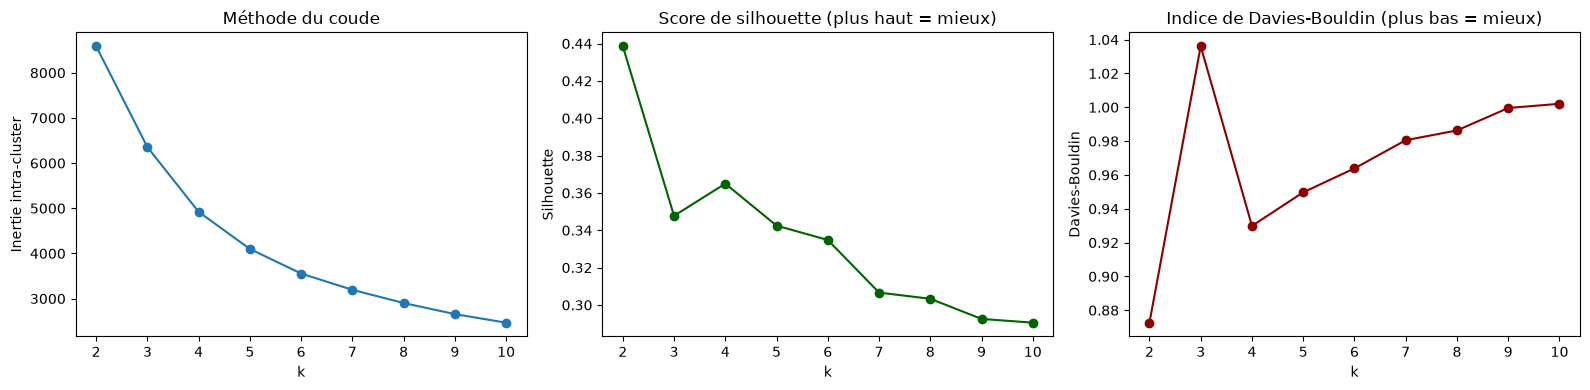

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(resultats.k, resultats.inertie, "o-")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie intra-cluster")

axes[1].plot(resultats.k, resultats.silhouette, "o-", color="darkgreen")
axes[1].set_title("Score de silhouette (plus haut = mieux)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(resultats.k, resultats.davies_bouldin, "o-", color="darkred")
axes[2].set_title("Indice de Davies-Bouldin (plus bas = mieux)")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.savefig(FIG / "choix_k_metriques.png", dpi=120)
plt.show()

## 3. Stabilité de la partition

Un bon score de silhouette sur un seul run ne garantit rien : si KMeans converge vers des
partitions très différentes selon la graine aléatoire, le k n'est pas fiable. On relance chaque k
plusieurs fois et on compare les partitions deux à deux avec l'**Adjusted Rand Index** (ARI, 1 =
partitions identiques, 0 = accord aléatoire).

In [5]:
N_RUNS = 8
stabilite = []

for k in K_RANGE:
    labels_runs = []
    for run in range(N_RUNS):
        km = KMeans(n_clusters=k, n_init=10, random_state=run)
        labels_runs.append(km.fit_predict(X[FEATURES]))

    aris = [
        adjusted_rand_score(labels_runs[i], labels_runs[j])
        for i in range(N_RUNS) for j in range(i + 1, N_RUNS)
    ]
    stabilite.append({"k": k, "ari_moyen": np.mean(aris), "ari_min": np.min(aris)})

stabilite = pd.DataFrame(stabilite)
resultats = resultats.merge(stabilite, on="k")
display(resultats)

,k,inertie,silhouette,davies_bouldin,ari_moyen,ari_min
0,2,8588.985343,0.438602,0.872669,0.993489,0.987086
1,3,6354.343153,0.347745,1.036142,0.976753,0.951118
2,4,4921.233345,0.364971,0.929878,0.995633,0.992534
3,5,4099.106079,0.342496,0.949741,0.988591,0.970275
4,6,3554.696269,0.334796,0.963894,0.922608,0.830684
5,7,3194.500972,0.306636,0.980536,0.869778,0.769882
6,8,2902.433885,0.303315,0.986322,0.951089,0.905497
7,9,2656.562328,0.292524,0.999586,0.927136,0.773697
8,10,2467.378466,0.290525,1.002066,0.918970,0.769373


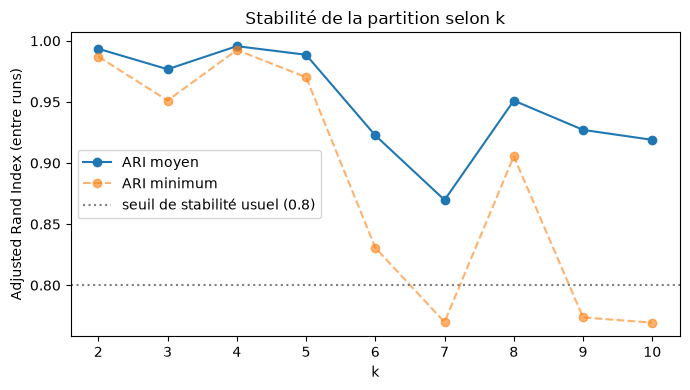

k dont la stabilité est insuffisante (ARI moyen < 0.8) : []


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(resultats.k, resultats.ari_moyen, "o-", label="ARI moyen")
plt.plot(resultats.k, resultats.ari_min, "o--", label="ARI minimum", alpha=0.6)
plt.axhline(0.8, color="grey", linestyle=":", label="seuil de stabilité usuel (0.8)")
plt.xlabel("k")
plt.ylabel("Adjusted Rand Index (entre runs)")
plt.title("Stabilité de la partition selon k")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "choix_k_stabilite.png", dpi=120)
plt.show()

print("k dont la stabilité est insuffisante (ARI moyen < 0.8) :",
      resultats.loc[resultats.ari_moyen < 0.8, "k"].tolist())

## 4. Choix de k : statistique + métier

Règle de sélection : parmi les k stables (ARI moyen ≥ 0.8), on retient celui qui maximise la
silhouette **dans une fourchette interprétable pour le marketing (4 à 6 segments)** — un k
statistiquement optimal mais à 9 segments n'est pas actionnable en pratique.

In [7]:
K_MIN_METIER, K_MAX_METIER = 4, 6

candidats = resultats[
    (resultats.ari_moyen >= 0.8)
    & (resultats.k >= K_MIN_METIER)
    & (resultats.k <= K_MAX_METIER)
].sort_values("silhouette", ascending=False)

print("Candidats stables et interprétables (k entre "
      f"{K_MIN_METIER} et {K_MAX_METIER}) :")
display(candidats)

if len(candidats) > 0:
    K_FINAL = int(candidats.iloc[0]["k"])
else:
    # repli : k stable le plus proche de la fourchette métier
    stables = resultats[resultats.ari_moyen >= 0.8]
    K_FINAL = int(stables.iloc[(stables.k - K_MIN_METIER).abs().argsort().iloc[0]]["k"])
    print("Aucun candidat stable dans la fourchette métier -> repli sur le k stable le plus proche.")

print(f"\n=> k retenu : {K_FINAL}")

Candidats stables et interprétables (k entre 4 et 6) :


,k,inertie,silhouette,davies_bouldin,ari_moyen,ari_min
2,4,4921.233345,0.364971,0.929878,0.995633,0.992534
3,5,4099.106079,0.342496,0.949741,0.988591,0.970275
4,6,3554.696269,0.334796,0.963894,0.922608,0.830684



=> k retenu : 4


> **À documenter dans le rapport :** remplacer cette justification automatique par une phrase
> explicite si le k choisi par la règle ci-dessus diffère de votre lecture des graphes (coude,
> silhouette) — la règle est un guide, pas un verdict à suivre aveuglément.

## 5. Modèle final et projection PCA

In [8]:
km_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
X["cluster"] = km_final.fit_predict(X[FEATURES])

print("Taille des segments :")
display(X["cluster"].value_counts().sort_index())

print(f"\nSilhouette finale (k={K_FINAL}) :",
      round(silhouette_score(X[FEATURES], X["cluster"]), 3))

Taille des segments :


cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


Silhouette finale (k=4) : 0.365


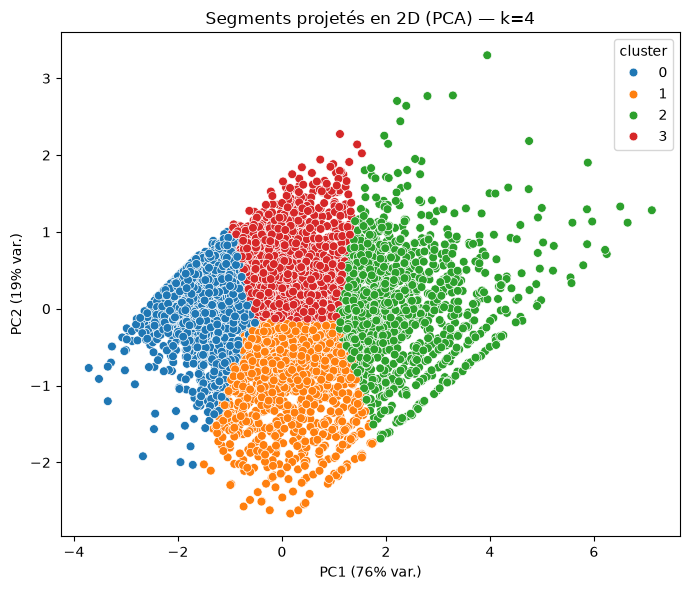

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X[FEATURES])

plt.figure(figsize=(7, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=X["cluster"], palette="tab10", s=40)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var.)")
plt.title(f"Segments projetés en 2D (PCA) — k={K_FINAL}")
plt.tight_layout()
plt.savefig(FIG / "clusters_pca.png", dpi=120)
plt.show()

> **Lecture :** des clusters bien séparés visuellement en 2D confirment la silhouette ; des
> clusters qui se chevauchent fortement ici, malgré une silhouette correcte en 3D (R/F/M), méritent
> d'être regardés de plus près en Partie 4 avant de les présenter comme définitifs.

## 6. Sauvegarde

In [10]:
clusters = X[["CustomerID", "cluster"]].merge(rfm, on="CustomerID", how="left")

assert clusters["cluster"].isna().sum() == 0
assert len(clusters) == len(X), "Perte de lignes lors de la fusion avec rfm_features"

clusters.to_parquet(PROC / "clusters.parquet", index=False)

print("Sauvegardé :", PROC / "clusters.parquet")
print("Shape :", clusters.shape)
display(clusters.head())

Sauvegardé : ../data/processed/clusters.parquet
Shape : (5878, 13)


,CustomerID,cluster,Recence,Frequence,Montant,Anciennete,NbArticles,PanierMoyen,R_score,F_score,M_score,RFM_score,RFM_somme
0,12346,2,326,12,77556.46,726,74285,6463.038333,2,5,5,255,12
1,12347,2,2,8,4921.53,404,2967,615.191250,5,4,5,545,14
2,12348,3,75,5,2019.40,438,2714,403.880000,3,4,4,344,11
3,12349,1,19,4,4428.69,589,1624,1107.172500,5,3,5,535,13
4,12350,0,310,1,334.40,310,197,334.400000,2,1,2,212,5


**Mini-résumé** : k a été choisi en combinant trois métriques statistiques (coude, silhouette,
Davies-Bouldin) et un test de stabilité multi-runs (ARI), dans une fourchette interprétable pour le
métier (4-6 segments). Le résultat (`clusters.parquet`) associe chaque `CustomerID` à un numéro de
segment et conserve les valeurs RFM en unités réelles pour l'interprétation en Partie 4.